# Dummy Classifer

This notebook aims to build dummy classifier from `sklearn` library, evaluate results without SMOTE implement SMOTE, and evaluate results. From this notebook onwards, we shall be using industry standard MLFlow to log all experiments. After reading many articles, I would say MLFlow would be a more useful skill to acquire than WanDB, since it is deeply integrated with industry-leading cloud and data platforms, such as Databricks, Azure, AWS. Learning MLFlow allows me to equip skills like easy experiment tracking, logging, registry and deployment of ML models. Widely used across enterprises, it can help me more in my job search compared to WandB.


## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import pandas as pd 
import numpy as np 
from IPython.display import HTML, display 

# Data Visualization Libraries 
import src.plots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning Libraries
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Data Preparation and Evaluation Libraries
import src.data_preparation as data_prep
from src.evaluation import ResultsAnalyser

print(f"Current pandas version: {pd.__version__}")

2025-10-19 19:46:57.879 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/lunlun/Downloads/Github/Fraud-Detection-ML


Current pandas version: 2.0.3


## 1. Read & Standardise Data


In [2]:
X_train , y_train= pd.read_csv("data/processed/X_train.csv"), pd.read_csv("data/processed/y_train.csv")
X_val , y_val= pd.read_csv("data/processed/X_val.csv"), pd.read_csv("data/processed/y_val.csv")
X_test , y_test= pd.read_csv("data/processed/X_test.csv"), pd.read_csv("data/processed/y_test.csv")

display(X_train.head(), X_val.head(), X_test.head()) 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,68504.0,-1.466684,0.437843,1.798819,-1.955137,-1.436692,0.141052,-1.339819,1.163623,-1.273979,...,-0.124413,0.585563,1.189609,-0.368531,-0.323312,0.410506,-0.108637,-0.307629,-0.095969,8.99
1,163410.0,2.099619,-0.023369,-1.369803,0.224338,0.339848,-0.669249,0.224435,-0.315935,0.446580,...,-0.136091,-0.319857,-0.739342,0.237677,-0.748881,-0.181017,0.244591,-0.063086,-0.065425,5.99
2,1719.0,-1.960524,1.438062,-0.067457,-0.382996,0.369982,-0.113959,0.181212,0.504365,0.062941,...,0.029317,-0.448709,-0.847225,0.241987,-1.030383,0.234938,0.156216,0.338689,0.100345,16.00
3,123093.0,1.838230,-0.641136,-0.425984,0.560873,-0.835237,0.005472,-1.102837,0.245831,1.666006,...,-0.030587,0.150565,0.399034,0.188064,0.483990,-0.557038,0.485454,0.003685,0.010003,75.34
4,145015.0,0.751899,-2.034001,-1.388385,1.703266,-0.369474,0.535422,0.645324,-0.170321,0.656970,...,1.167378,-0.014687,-1.277865,-0.182382,0.156963,-0.475163,-1.138433,-0.064637,0.087829,648.84


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,41473.0,-1.163140,1.524494,0.125988,0.759396,-1.394477,0.012822,1.388111,0.164741,-0.131994,...,-0.181672,0.019196,0.253583,-0.114741,0.003827,-0.147815,-0.297582,0.294491,0.121599,243.22
1,126996.0,-2.221641,0.847537,0.901440,-0.748277,1.198836,-1.474504,0.468470,-0.151557,0.373888,...,-0.096335,-0.572575,-0.970201,-0.689011,0.022912,0.609070,0.361978,0.651167,0.195076,2.99
2,152682.0,2.174427,-1.536638,-0.735840,-1.633974,-1.286581,-0.247566,-1.248885,-0.086531,-1.409128,...,-0.278173,-0.076779,0.238264,0.157670,-0.458794,-0.259977,-0.173300,0.023699,-0.049979,57.00
3,39051.0,-0.312073,0.198716,1.352627,-0.799472,-0.537772,-0.863334,0.553266,-0.167900,-1.827079,...,0.307295,0.009406,-0.195087,0.270101,0.585419,-0.519895,-0.506865,0.113223,0.142724,69.00
4,153099.0,-1.944015,1.161258,-1.033634,-1.380662,-0.286535,-0.790003,0.204989,1.141851,-0.373392,...,-0.663504,0.491118,0.852265,-0.330785,-0.569392,0.368715,-0.465374,-0.493415,-0.163518,54.12


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,11.50
1,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.94
2,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,91.28
3,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,228.00
4,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,1.41


In [3]:
# - Observe that Features aren't scaled - 
display(X_train.describe(), X_val.describe(), X_test.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,...,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000,170235.000000
mean,94935.856933,0.004440,-0.005326,0.004378,-0.001367,0.005091,-0.002076,0.002997,0.000855,-0.000145,...,-0.000686,0.002256,0.000409,0.001689,-0.001262,0.001001,0.000174,0.001545,0.000549,88.160599
std,47513.476716,1.951666,1.658104,1.504313,1.418094,1.361377,1.323434,1.198507,1.167873,1.095412,...,0.766421,0.722331,0.723021,0.622699,0.605950,0.522382,0.481316,0.394118,0.333071,246.449922
min,0.000000,-56.407510,-72.715728,-31.813586,-5.600607,-32.092129,-26.160506,-41.506796,-73.216718,-13.434066,...,-23.646890,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000
25%,54203.000000,-0.915610,-0.599787,-0.884126,-0.848872,-0.689504,-0.768228,-0.552723,-0.208420,-0.644021,...,-0.212373,-0.227712,-0.541024,-0.162658,-0.356076,-0.317921,-0.326713,-0.070483,-0.052924,5.680000
50%,84965.000000,0.018111,0.063911,0.178274,-0.021957,-0.052732,-0.274984,0.041558,0.022851,-0.050545,...,-0.062879,-0.028403,0.008139,-0.011527,0.039898,0.016721,-0.051937,0.001463,0.011363,22.040000
75%,139339.000000,1.315404,0.799517,1.030577,0.742515,0.614333,0.399837,0.572254,0.326151,0.597192,...,0.132862,0.187180,0.527584,0.148332,0.439223,0.351870,0.239980,0.090966,0.078156,77.575000
max,172788.000000,2.454930,21.467203,9.382558,16.875344,34.801666,21.393069,34.303177,19.587773,15.594995,...,39.420904,22.614889,10.503090,22.528412,4.016342,7.519589,3.517346,12.152401,33.847808,19656.530000


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,...,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000
mean,94793.326760,0.006789,-0.006216,-0.004610,-0.004000,0.004490,-0.001615,-0.003072,-0.003424,-0.011099,...,0.004654,-0.002494,-0.000935,-0.005989,0.003953,-0.002018,0.000703,0.002090,0.002142,89.066701
std,47412.603756,1.934133,1.623902,1.516101,1.413563,1.354439,1.323312,1.205188,1.173744,1.089942,...,0.738380,0.722011,0.728393,0.634589,0.605401,0.519375,0.481597,0.379765,0.302721,243.707834
min,0.000000,-46.855047,-45.607973,-33.680984,-5.683171,-31.356750,-17.574835,-43.557242,-41.484823,-13.320155,...,-23.420173,-22.797604,-8.887017,-32.828995,-2.824849,-8.696627,-2.241620,-7.263482,-8.364853,0.000000
25%,54312.000000,-0.916829,-0.604572,-0.897445,-0.850274,-0.688378,-0.770161,-0.551943,-0.209287,-0.645433,...,-0.208978,-0.229401,-0.543008,-0.161792,-0.351543,-0.316889,-0.326141,-0.070665,-0.051890,5.740000
50%,84538.000000,0.018690,0.063344,0.178381,-0.022240,-0.051875,-0.278358,0.038461,0.020526,-0.062466,...,-0.059849,-0.029537,0.004916,-0.010896,0.045117,0.014190,-0.051018,0.001665,0.011650,22.240000
75%,139452.000000,1.315404,0.806103,1.018272,0.737329,0.618137,0.390502,0.570868,0.323682,0.586635,...,0.135826,0.186117,0.532637,0.147123,0.442777,0.348743,0.240275,0.092773,0.080471,78.320000
max,172792.000000,2.451888,22.057729,4.226108,13.129143,24.655965,21.190194,30.897666,20.007208,9.234623,...,23.649095,27.202839,8.316275,18.364472,3.979637,5.473885,3.155327,8.088549,14.974180,11789.840000


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,...,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,94454.496722,0.009476,0.001520,-0.000459,-0.006730,-0.010626,0.002146,0.003085,-0.003413,0.003552,...,-0.001660,-0.006127,-0.000368,0.001912,0.000904,-0.002148,-0.000478,0.002089,-0.001054,88.814933
std,47451.115498,1.950968,1.634998,1.514327,1.403031,1.444329,1.365524,1.331946,1.217134,1.101218,...,0.810533,0.730477,0.725294,0.615650,0.604875,0.519568,0.484717,0.415767,0.336981,268.131582
min,2.000000,-37.558067,-38.305310,-48.325589,-5.416315,-113.743307,-21.929312,-33.239328,-50.688419,-10.842526,...,-54.497720,-22.889347,-7.105990,-36.666000,-2.766638,-6.712624,-1.715640,-9.895244,-15.430084,0.000000
25%,54059.000000,-0.916543,-0.597568,-0.897331,-0.853980,-0.691636,-0.769724,-0.552502,-0.209729,-0.643965,...,-0.210928,-0.229364,-0.546949,-0.159037,-0.352908,-0.316651,-0.327523,-0.071009,-0.053493,5.490000
50%,84470.000000,0.029038,0.064518,0.186424,-0.023224,-0.058079,-0.272845,0.040898,0.020619,-0.048966,...,-0.062994,-0.032642,0.004138,-0.009930,0.040616,0.016764,-0.054226,0.001358,0.010534,21.585000
75%,139035.000000,1.318946,0.796301,1.025895,0.732642,0.600157,0.393584,0.564698,0.326667,0.603520,...,0.131905,0.183733,0.526069,0.146160,0.438291,0.348999,0.241373,0.090439,0.076436,76.497500
max,172786.000000,2.430507,16.697832,3.924953,15.304184,32.911462,73.301626,120.589494,15.794136,10.392889,...,24.133894,20.063786,8.272233,19.002942,4.584549,4.808122,3.463246,31.612198,15.866721,25691.160000


In [4]:
# - Scaling of Features - 
import src.data_preparation as data_prep
scaler = data_prep.DataStandardiser()
X_train_scaled, X_val_scaled, X_test_scaled = scaler.fit_transform_splits(X_train, X_val, X_test)

# - Observe Features are scaled to the same range - 
display(X_train_scaled.describe(), X_val_scaled.describe(), X_test_scaled.describe())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,...,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05
mean,8.932132e-17,2.637901e-17,-1.060169e-17,1.030952e-17,-1.552688e-17,-1.260516e-17,2.170425e-18,-1.352341e-17,3.172159e-18,7.513008e-18,...,7.846920e-18,-1.669557e-18,1.101908e-17,-3.297376e-18,-3.145029e-17,-2.337380e-18,-1.602775e-17,-6.302579e-18,-3.589548e-18,7.713355e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.998089e+00,-2.890460e+01,-4.385165e+01,-2.115123e+01,-3.948438e+00,-2.357710e+01,-1.976563e+01,-3.463469e+01,-6.269327e+01,-1.226384e+01,...,-3.085285e+01,-4.822267e+01,-1.512209e+01,-7.196027e+01,-4.679219e+00,-1.971052e+01,-5.411684e+00,-5.726023e+01,-3.516209e+01,-3.577232e-01
25%,-8.572931e-01,-4.714192e-01,-3.585194e-01,-5.906398e-01,-5.976386e-01,-5.102166e-01,-5.789135e-01,-4.636778e-01,-1.791937e-01,-5.877955e-01,...,-2.762023e-01,-3.183692e-01,-7.488514e-01,-2.639275e-01,-5.855511e-01,-6.105171e-01,-6.791548e-01,-1.827592e-01,-1.605461e-01,-3.346759e-01
50%,-2.098539e-01,7.004965e-03,4.175699e-02,1.155985e-01,-1.451939e-02,-4.247452e-02,-2.062127e-01,3.217413e-02,1.883438e-02,-4.601050e-02,...,-8.114761e-02,-4.244436e-02,1.069129e-02,-2.122442e-02,6.792648e-02,3.009123e-02,-1.082681e-01,-2.096535e-04,3.246766e-02,-2.682930e-01
75%,9.345406e-01,6.717175e-01,4.854011e-01,6.821729e-01,5.245662e-01,4.475205e-01,3.036905e-01,4.749735e-01,2.785386e-01,5.453091e-01,...,1.742499e-01,2.560106e-01,7.291303e-01,2.354969e-01,7.269346e-01,6.716726e-01,4.982311e-01,2.268882e-01,2.330045e-01,-4.295246e-02
max,1.638532e+00,1.255593e+00,1.295009e+01,6.234214e+00,1.190102e+01,2.555992e+01,1.616643e+01,2.861917e+01,1.677149e+01,1.423682e+01,...,5.143609e+01,3.130516e+01,1.452616e+01,3.617607e+01,6.630274e+00,1.439292e+01,7.307421e+00,3.083059e+01,1.016220e+02,7.940123e+01


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,...,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000
mean,-0.003000,0.001203,-0.000537,-0.005975,-0.001856,-0.000442,0.000348,-0.005063,-0.003663,-0.010001,...,0.006968,-0.006576,-0.001860,-0.012330,0.008606,-0.005780,0.001098,0.001382,0.004783,0.003677
std,0.997880,0.991019,0.979376,1.007839,0.996808,0.994907,0.999910,1.005577,1.005030,0.995009,...,0.963416,0.999559,1.007433,1.019098,0.999097,0.994246,1.000586,0.963585,0.908881,0.988877
min,-1.998089,-24.010069,-27.502962,-22.392592,-4.006660,-23.036926,-13.278190,-36.345524,-35.522521,-12.159852,...,-30.557033,-31.564362,-12.292114,-52.723391,-4.659782,-16.649977,-4.657645,-18.433687,-25.116036,-0.357723
25%,-0.854999,-0.472044,-0.361405,-0.599494,-0.598627,-0.509390,-0.580375,-0.463027,-0.179936,-0.589084,...,-0.271773,-0.320708,-0.751595,-0.262537,-0.578072,-0.608542,-0.677965,-0.183221,-0.157442,-0.334432
50%,-0.218841,0.007301,0.041415,0.115670,-0.014719,-0.041845,-0.208762,0.029590,0.016844,-0.056893,...,-0.077193,-0.044014,0.006233,-0.020211,0.076539,0.025247,-0.106358,0.000304,0.033329,-0.267481
75%,0.936919,0.671717,0.489373,0.673994,0.520910,0.450315,0.296637,0.473817,0.276424,0.535671,...,0.178117,0.254539,0.736119,0.233556,0.732800,0.665686,0.498843,0.231474,0.239955,-0.039930
max,1.638617,1.254034,13.306231,2.806426,9.259294,18.107366,16.013136,25.777705,17.130638,8.430430,...,30.857514,37.656770,11.501594,29.489126,6.569699,10.476809,6.555277,20.519304,44.956384,47.481102


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,...,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,-0.010131,0.002581,0.004129,-0.003216,-0.003782,-0.011545,0.003190,0.000074,-0.003654,0.003375,...,-0.001270,-0.011605,-0.001074,0.000359,0.003574,-0.006030,-0.001356,0.001380,-0.004812,0.002655
std,0.998690,0.999646,0.986068,1.006660,0.989381,1.060935,1.031806,1.111341,1.042183,1.005303,...,1.057559,1.011280,1.003147,0.988684,0.998228,0.994616,1.007068,1.054934,1.011743,1.087979
min,-1.998046,-19.246442,-23.098725,-32.127700,-3.818481,-83.554194,-16.568485,-27.736527,-43.403192,-9.898022,...,-71.106072,-31.691372,-9.828792,-58.885307,-4.563715,-12.851976,-3.564847,-25.111305,-46.328475,-0.357723
25%,-0.860324,-0.471897,-0.357181,-0.599417,-0.601240,-0.511783,-0.580044,-0.463493,-0.180315,-0.587745,...,-0.274317,-0.320657,-0.757046,-0.258112,-0.580323,-0.608087,-0.680836,-0.184093,-0.162256,-0.335447
50%,-0.220272,0.012604,0.042123,0.121016,-0.015413,-0.046402,-0.204596,0.031624,0.016924,-0.044569,...,-0.081297,-0.048313,0.005157,-0.018659,0.069111,0.030175,-0.113025,-0.000475,0.029977,-0.270139
75%,0.928142,0.673532,0.483461,0.679061,0.517604,0.437107,0.298966,0.468669,0.278980,0.551086,...,0.173001,0.251239,0.727034,0.232009,0.725397,0.666177,0.501125,0.225552,0.227840,-0.047325
max,1.638490,1.243079,10.073677,2.606231,10.793076,24.171464,55.389165,100.614222,13.523153,9.487812,...,31.490066,27.773390,11.440680,30.514456,7.567990,9.202330,7.195020,80.206288,47.636122,103.887534


In [5]:
import src.data_preparation as data_prep
data_prep.check_scaling_validity(X_train_scaled, X_val_scaled, X_test_scaled)


Feature means after scaling:
 Time     -0.002626
V1        0.000757
V2        0.000718
V3       -0.001838
V4       -0.001128
V5       -0.002397
V6        0.000708
V7       -0.000998
V8       -0.001463
V9       -0.001325
V10      -0.000262
V11       0.000210
V12       0.000173
V13      -0.000470
V14       0.001343
V15       0.000085
V16       0.001808
V17       0.002217
V18      -0.003085
V19       0.000234
V20       0.001139
V21      -0.003636
V22      -0.000587
V23      -0.002394
V24       0.002436
V25      -0.002362
V26      -0.000052
V27       0.000552
V28      -0.000006
Amount    0.001266
dtype: float64
-----------------------------------
Feature std devs after scaling:
 Time      0.999320
V1        0.998138
V2        0.993127
V3        1.002907
V4        0.997246
V5        1.011485
V6        1.006423
V7        1.024331
V8        1.009577
V9        1.000076
V10       1.000402
V11       0.998350
V12       1.000504
V13       1.000368
V14       0.996523
V15       1.000969
V16       0.

As observed, all scaling worked correctly since scaling should place features of different scales to the same scale where mean is near 0 and standard deviation is 1. We can proceed to the next step.


## 2. Dummy Classifier (Most Frequent) Model Building

To check effect of SMOTE, lets train a dummy classifier which relies on random guessing. For imbalanced datasets, we can use `most_frequent` method since it simply guesses the most frequently appearing label (non-fraud). This label is often used for extremely imbalanced datasets.


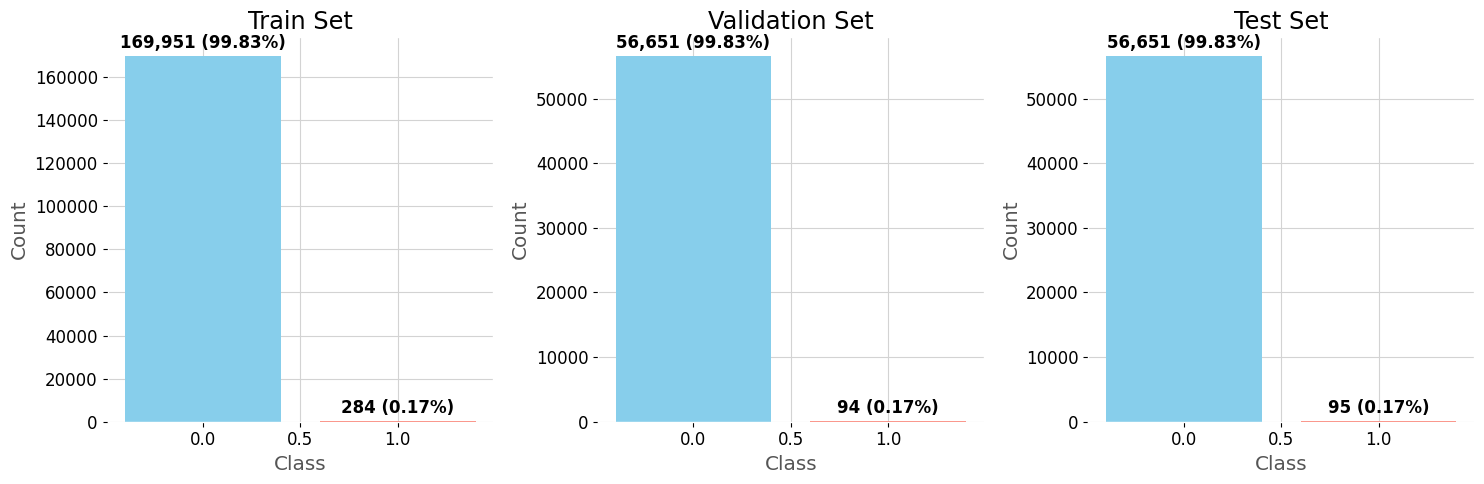

In [6]:
# - Check Class Distribution - 
src.plots.plot_class_distribution()

In [7]:
# - Instantiate and Train Dummy Classifier - 
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,42
,constant,None


In [8]:
# - Make predictions on the test data - 
y_pred = dummy.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

✅ Dummy Classifier (Most Frequent) Results Analysis
Accuracy:  0.9983
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9992     56651
           1     0.0000    0.0000    0.0000        95

    accuracy                         0.9983     56746
   macro avg     0.4992    0.5000    0.4996     56746
weighted avg     0.9967    0.9983    0.9975     56746

--------------------

✅ Confusion Matrix:


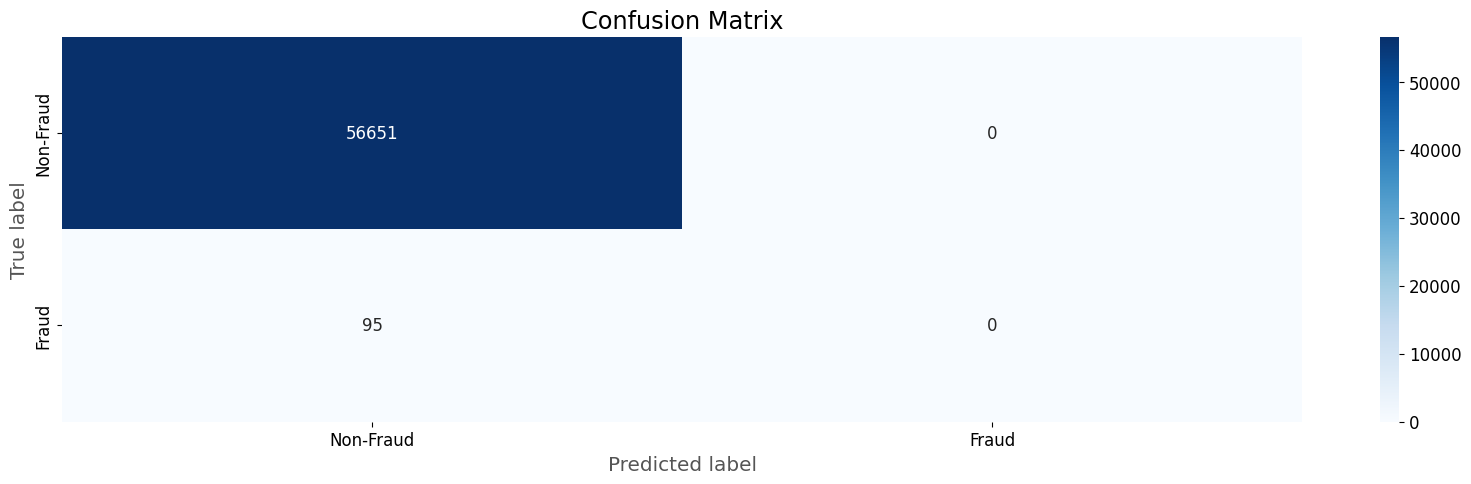

In [9]:
# - Analyze Dummy Classifier Results -
analyzer = ResultsAnalyser("Dummy Classifier (Most Frequent)")
dummy_metrics = analyzer.analyze_predictions(
    y_true=y_test, 
    y_pred=y_pred, 
    class_labels=['Non-Fraud', 'Fraud']
)

| **Metric**                        | **Why it matters**                                   | **What to compare**                                                         |
| --------------------------------- | ---------------------------------------------------- | --------------------------------------------------------------------------- |
| **Recall for fraud (class 1)**    | Shows how many actual fraud cases the model catches. | Models built should have **recall > 0** for fraud (baseline = 0) (no SMOTE) |
| **Precision for fraud (class 1)** | Shows how many predicted frauds are correct.         | Higher than 0 means it’s catching real frauds.                              |
| **F1-score for fraud (class 1)**  | Balances recall and precision.                       | Any F1 > 0 beats the baseline.                                              |


In [10]:
# - MLFlow Experiment Tracking - 

## 3. SMOTE Application

Now, lets observe the effectiveness of applying SMOTE to our training data. SMOTE is one of the most famous techniques to address class imbalance. To put it simply, imagine plotting of all data points in a feature space. The SMOTE algorithm will randomly select 1 data point from the minority class and find its k nearest neighbors from minority class (default k = 5). It randomly selects 1 of the neighbors, draws a line between this point and the data point aforementioned. It then creates a **new synthetic data point** on this line. The algorithm repeats until **a desired number of synthetic data points** is reached.

This reduces overfitting of our ML models to the majority class and improves model performance in real life (since we are aiming for our built ML models to see patterns in the minority class, while not raising too many false alarms).


In [11]:
# - Apply SMOTE using ApplySmote class -
smote_balancer = data_prep.ApplySmote(random_state=42)
X_train_smote, y_train_smote = smote_balancer.fit_resample(X_train_scaled, y_train)

# - Display class distribution before and after -
smote_balancer.print_class_distribution(y_train, y_train_smote)

✅ Before SMOTE:
Class
0        169951
1           284
Name: count, dtype: int64
-------------------------
✅ After SMOTE:
Class
0        169951
1        169951
Name: count, dtype: int64


## 4. Dummy Classifier (Uniform) with SMOTE

Now let's test a `uniform` strategy dummy classifier with the SMOTE-balanced data. The uniform strategy provides a more realistic baseline since it randomly predicts each class with equal probability, giving us meaningful recall and precision baselines to compare against real models.


✅ Dummy Classifier (With SMOTE) Results Analysis
Accuracy:  0.5011
Precision: 0.0014
Recall:    0.4105
F1-Score:  0.0027

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.5012    0.6673     56651
           1     0.0014    0.4105    0.0027        95

    accuracy                         0.5011     56746
   macro avg     0.4997    0.4559    0.3350     56746
weighted avg     0.9964    0.5011    0.6662     56746

--------------------

✅ Confusion Matrix:


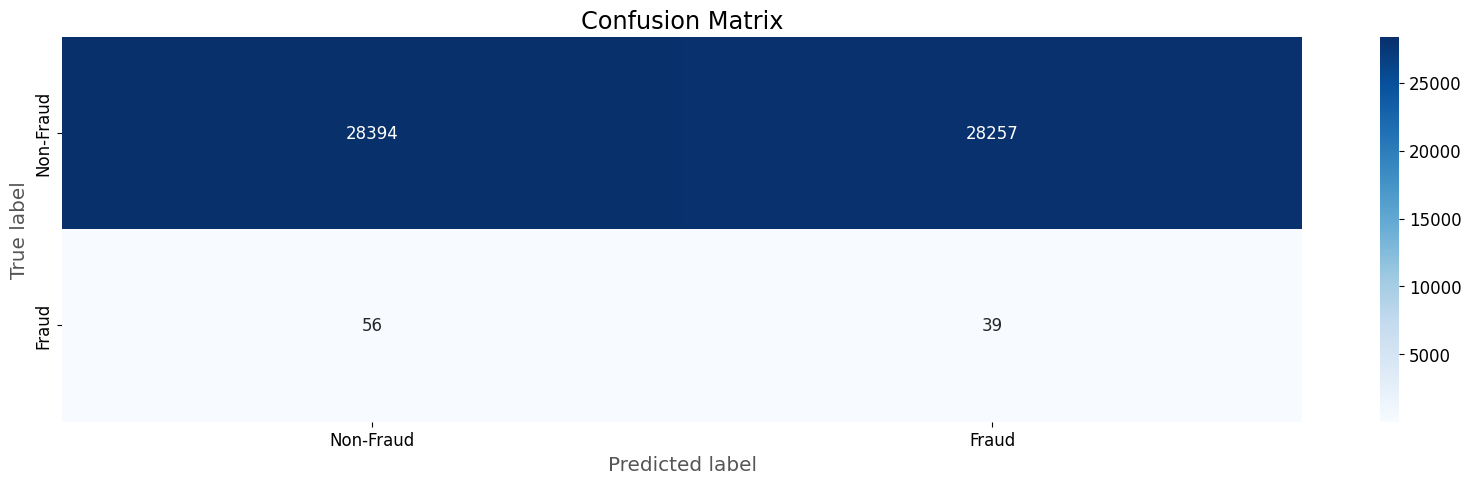

In [12]:
# - Train Dummy Classifier with SMOTE Data -
dummy_smote = DummyClassifier(strategy='uniform', random_state=42)
dummy_smote.fit(X_train_smote, y_train_smote)

# - Make predictions -
y_pred_smote = dummy_smote.predict(X_test_scaled)

# - Analyze Results -
analyzer_smote = ResultsAnalyser("Dummy Classifier (With SMOTE)")
smote_metrics = analyzer_smote.analyze_predictions(
    y_true=y_test, 
    y_pred=y_pred_smote, 
    class_labels=['Non-Fraud', 'Fraud']
)

In [14]:
# - Compare Results -
print("✅ Dummy Classifier Comparison")
print("=" * 40)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Most Frequent': [
        dummy_metrics['accuracy'],
        dummy_metrics['precision'], 
        dummy_metrics['recall'],
        dummy_metrics['f1_score']
    ],
    'Uniform (With SMOTE)': [
        smote_metrics['accuracy'],
        smote_metrics['precision'],
        smote_metrics['recall'], 
        smote_metrics['f1_score']
    ]
}).round(4)

display(comparison_df)


✅ Dummy Classifier Comparison


,Metric,Most Frequent,Uniform (With SMOTE)
0,Accuracy,0.9983,0.5011
1,Precision,0.0000,0.0014
2,Recall,0.0000,0.4105
3,F1-Score,0.0000,0.0027


## Summary

In this notebook, we successfully established baseline performance using dummy classifiers
- **Dummy Classifier Issues**: 
    - **Extremely Low Precision (Fraud Class)**: Predicts too many fraudulent cases when they are not 
    - **Unsatisfactory Recall (Fraud Class)**: Catches unsatisfactory number of fraudulent cases amongst true fraudulent transactions  
    - **Near-to-Perfect Precision (Non-Fraud Class)**: Correctly catches almost all non-fraudulent cases amongst its non-fraudlent predictions 
    - **Unsatisfactory Recall (Non-Fraud Class)**: Out of all true non-fraud transactions, only predicts ~50% non-fraud transactions 

- **Established meaningful baselines**: Uniform strategy provides realistic targets for real models
- **Demonstrated SMOTE effect**: Balanced classes from 284:169,951 to 1:1 ratio

### Baseline Results (Important: Fraud Class)

| Strategy             | Accuracy   | Precision | Recall     | F1-Score  |
| -------------------- | ---------- | --------- | ---------- | --------- |
| Most Frequent        | 99.83%     | 0.00%     | 0.00%      | 0.00%     |
| **Uniform (Target)** | **50.11%** | **0.14%** | **41.05%** | **0.27%** |

### Next Steps

- Build Naive Bayes, LightGBM, XGBoost, ANN, QML models etc
- Target: **Recall > 41%** and **Precision > 0.14%** on Fraud Class
- Use `ApplySmote` class for consistent SMOTE application
- Implement MLflow experiment tracking for all models
